# **Deliverable 5: Nuclear Medicine, SPECT, and PET**

---

## Overview

This deliverable covers key concepts from **Lectures 29–34**. The goal is to connect nuclear decay, radiopharmaceutical design, gamma-camera and SPECT system behavior, and the core physics behind PET. The final section briefly extends those ideas to hybrid imaging and clinical decision-making.

Upon successful completion, you will be able to:
1. **Apply** radioactive decay, effective half-life, and counting-statistics ideas to basic nuclear medicine calculations.
2. **Explain** how radiopharmaceutical choice, gamma-camera design, collimation, and energy windowing affect image quality.
3. **Compare** planar imaging, SPECT, and PET in terms of acquisition, reconstruction, corrections, and clinical use.
4. **Implement** compact computational models for decay/counting behavior and PET reconstruction.
5. **Evaluate** when hybrid imaging adds value and justify modality choices for selected clinical scenarios.

---

# Part 1: Radioactivity, Radiotracers, and Counting Fundamentals

## Key Concepts

**Activity and Decay:**
- $A(t)=A_0 e^{-\lambda t}$, where $\lambda=\ln 2 / T_{1/2}$
- After one half-life, activity falls to 50% of its original value
- Short half-life lowers long-term dose but can reduce available counts if imaging is delayed

**Physical, Biological, and Effective Half-Life:**
- Physical half-life: radioactive decay only
- Biological half-life: physiologic clearance only
- Effective half-life: $\frac{1}{T_{eff}}=\frac{1}{T_p}+\frac{1}{T_b}$
- Effective half-life determines how quickly signal availability drops in patients

**Tracer Principle and Radiopharmaceutical Design:**
- The tracer should follow the biology of interest without perturbing it substantially
- Good tracers balance targeting, photon yield, acceptable dose, and practical production/logistics
- Tc-99m is widely used because of its 140 keV gamma emission and convenient 6 h half-life

**Counting Statistics:**
- Nuclear medicine data are count-limited and approximately Poisson distributed
- If counts = $N$, then standard deviation is about $\sqrt{N}$
- Relative noise decreases as counts increase, but higher counts usually require more time or more administered activity

## 1.1 Decay, Effective Half-Life, and Radiotracer Selection

### **Questions 1**
A patient is injected with $740\ \mathrm{MBq}$ of Tc-99m, which has a physical half-life of 6 h.

- a) Compute the remaining activity after 3 h, 6 h, and 18 h.

    The decay constant $\lambda = \frac{\ln(2)}{T_{1/2}} = \frac{\ln(2)}{6 \text{ h}} = 0.1155 \text{ h}^{-1}$, therefore:

    After 3 hours: $A(t)=A_0 e^{-\lambda t}= 740\ \mathrm{MBq} \times e^{-0.1155 \text{ h}^{-1} \times 3\text{ h}} = 523\ \mathrm{MBq}$

    After 6 hours (one half-life): $A(t)=A_0 e^{-\lambda t}= 740\ \mathrm{MBq} \times e^{-0.1155 \text{ h}^{-1} \times 6\text{ h}} = 370\ \mathrm{MBq}$ (half of the initial activity)

    After 18 hours (three half-lives): $A(t)=A_0 e^{-\lambda t}= 740\ \mathrm{MBq} \times e^{-0.1155 \text{ h}^{-1} \times 18\text{ h}} = 92.5\ \mathrm{MBq}$ (one-eighth of the initial activity)

- b) If the biologic half-life of the tracer in the target organ is 12 h, compute the effective half-life.

    $$\frac{1}{T_{eff}}=\frac{1}{T_p}+\frac{1}{T_b} = \frac{1}{6\text{ h}}+\frac{1}{12\text{ h}} = \frac{1}{{4\text{ h}}}$$

    Thus, the effective half-life is 4 hours.

- c) Using your effective half-life, estimate the remaining activity after 3 h and briefly explain why effective half-life matters more clinically than physical half-life alone.

    The effective decay constant $\lambda = \frac{\ln(2)}{T_{1/2}} = \frac{\ln(2)}{4 \text{ h}} = 0.173 \text{ h}^{-1}$, therefore:

    $$A(t)=A_0 e^{-\lambda t}= 740\ \mathrm{MBq} \times e^{-0.173 \text{ h}^{-1} \times 3\text{ h}} = 440\ \mathrm{MBq}$$

    From the moment a radiotracer is injected into the body, two processes occur to reduce the dose that is present: physical decay and biological clearance. Both of these processes must be accounted for, or else the amount remaining in the body (and thus both the dose and the suitability for imaging at a given time) will be significantly overestimated. 

### **Questions 2**
You are choosing between two diagnostic tracers for the same biologic target.
1. Tracer A: 140 keV gamma emission, 6 h half-life, generator produced, modest target uptake
2. Tracer B: high-energy beta emission, 3 day half-life, excellent target uptake

- a) Which tracer is better suited to routine diagnostic imaging, and why?

    Tracer A is significantly better-suited to routine diagnostic imaging. Tracer B emits beta radiation, which is directly ionizing (and thus more dangerous) and cannot penetrate the body easily (so will not be significantly detected). In addition, it has a much longer half-life, meaning that it remains in the body contributing to dose long past any usefulness for imaging. Meanwhile, Tracer A produces gamma rays, which are indirectly ionizing and can penetrate the body much more easily, and has a long enough half life to be produced, administered, and scanned before decaying to no longer contribute to dose.

- b) Identify at least three characteristics of an ideal diagnostic radiopharmaceutical.

    An ideal diagnostic radiopharmaceutical should have:
    1. Long enough half-life to be administered and measured, but not longer than that in order to allow clearance from the body and reduce dose.
    2. Only gamma-ray emissions to improve image quality while keeping dose minimal (in contrast to alpha or beta particle emissions, which do not improve image quality but significantly increase dose)
    3. Gamma-ray energies between 100 and 200 keV to allow for a sufficient balance between penetration (which will be too low at lower energies) and resolution (which will be worse at higher energies due to the collimator).

- c) Explain the tracer principle and why it is central to nuclear medicine.

    The basic concept of the tracer principle is that trace amounts of radioactive isotopes of a given element in the human body can replace non-radioactive isotopes of that same element without significant bioeffects; this allows us to administer a small amount of radiotracer and track its motion through the body based on the radiation it gives off, forming the basis of the field of nuclear medicine.

## 1.2 Decay and Count-Statistics Simulation

### **Coding Exercise 1**
Build a compact simulation that connects tracer decay to count-limited image quality.

Tasks:
1. Simulate physical decay and effective decay for at least one tracer over a 24 h period.
2. Plot activity versus time and mark a plausible imaging time window.
3. Simulate Poisson-distributed count measurements at two or three expected count levels.
4. Compare the mean and variance of your simulated counts to the Poisson expectation.
5. Briefly explain how count level, acquisition time, and administered activity trade off against image noise.

=== Coding Exercise 1: Decay and Count Statistics ===


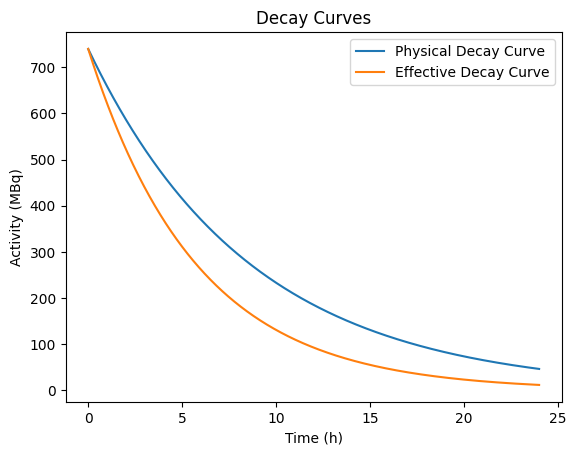

Initial activity:
Mean: 740.937 * 10^6 counts/second; expected 740.0 * 10^6 counts/second
Variance: 769.321 * 10^6 counts/second; expected 740.0 * 10^6 counts/second

After one half-life:
Mean: 370.303 * 10^6 counts/second; expected 370.0 * 10^6 counts/second
Variance: 368.759 * 10^6 counts/second; expected 370.0 * 10^6 counts/second

After two half-lives:
Mean: 185.124 * 10^6 counts/second; expected 185.0 * 10^6 counts/second
Variance: 192.817 * 10^6 counts/second; expected 185.0 * 10^6 counts/second

The mean is very close to the Poisson expectation in all cases;
however, for 1000 samples, the variance tends to vary around the mean
(whereas the expected variance for a Poisson distribution should be equal to the mean).
Trying with num_samples = 10000 makes the variance much less variable.

Just as with X-rays and CT scans, radiotracer detections are affected by quantum noise.
This quantum noise comes from the variance in the number of counts detected; thus, 
we can reduce it (and thus

In [35]:
print("=== Coding Exercise 1: Decay and Count Statistics ===")

import matplotlib.pyplot as plt
import numpy as np

# Example teaching values for this exercise (Tc-99m)
initial_activity_mbq = 740.0
physical_half_life_hours = 6.0
biological_half_life_hours = 12.0
hours = np.linspace(0.0, 24.0, 241)
num_trials = 1000 # repeated Poisson samples for estimating mean and variance

# TODO 1: Implement a function to compute decay constant from half-life.
def calculate_decay_constant(half_life):
    return np.log(2) / half_life

# TODO 2: Implement a function that returns activity vs time for exponential decay.
def activity_over_time(initial_activity, decay_constant, time):
    return initial_activity * np.exp(-decay_constant * time)

# TODO 3: Implement effective half-life and compute it for this tracer.
def effective_half_life(physical_half_life, biological_half_life):
    return 1 / (1/physical_half_life + 1/biological_half_life)

effective_half_life_hours = effective_half_life(physical_half_life_hours, biological_half_life_hours)

# TODO 4: Plot physical-decay and effective-decay activity curves over 24 h. Mark a plausible imaging time window on the plot.

time = np.linspace(0, 24, 1000)
physical_decay = [activity_over_time(
    initial_activity_mbq, calculate_decay_constant(physical_half_life_hours), t) for t in time]

effective_decay = [activity_over_time(
    initial_activity_mbq, calculate_decay_constant(effective_half_life_hours), t) for t in time]

plt.plot(time, physical_decay, time, effective_decay)
plt.title("Decay Curves"); plt.xlabel("Time (h)"); plt.ylabel("Activity (MBq)")
plt.legend(["Physical Decay Curve", "Effective Decay Curve"]); plt.show()

# TODO 5: Simulate Poisson-distributed counts at >=2 expected count levels using repeated trials.

mean_activity = np.random.poisson(initial_activity_mbq, num_trials)
half_mean_activity = np.random.poisson(initial_activity_mbq / 2, num_trials)
quarter_mean_activity = np.random.poisson(initial_activity_mbq / 4, num_trials)

# TODO 6: Compare sample mean/variance to the Poisson expectation and interpret.
print("Initial activity:")
print("Mean:", np.mean(mean_activity), "* 10^6 counts/second; expected", initial_activity_mbq, "* 10^6 counts/second")
print("Variance:", round(np.var(mean_activity), 3), "* 10^6 counts/second; expected", initial_activity_mbq, "* 10^6 counts/second")

print("\nAfter one half-life:")
print("Mean:", np.mean(half_mean_activity), "* 10^6 counts/second; expected", initial_activity_mbq/2, "* 10^6 counts/second")
print("Variance:", round(np.var(half_mean_activity), 3), "* 10^6 counts/second; expected", initial_activity_mbq/2, "* 10^6 counts/second")

print("\nAfter two half-lives:")
print("Mean:", np.mean(quarter_mean_activity), "* 10^6 counts/second; expected", initial_activity_mbq/4, "* 10^6 counts/second")
print("Variance:", round(np.var(quarter_mean_activity), 3), "* 10^6 counts/second; expected", initial_activity_mbq/4, "* 10^6 counts/second")

print("""
The mean is very close to the Poisson expectation in all cases;
however, for 1000 samples, the variance tends to vary around the mean
(whereas the expected variance for a Poisson distribution should be equal to the mean).
Trying with num_samples = 10000 makes the variance much less variable.""")

# TODO 7: Briefly explain how count level, acquisition time, and administered activity trade off against image noise.
print("""
Just as with X-rays and CT scans, radiotracer detections are affected by quantum noise.
This quantum noise comes from the variance in the number of counts detected; thus, 
we can reduce it (and thus improve the image SNR) by either choosing a radiotracer
with higher activity (and thus higher dose) or increasing the acquisition time of the scan.
Both of these increase the count level N; SNR for quantum noise = sqrt(N), so it improves.
""")

## 1.3 Gamma-Camera Foundations and Detector Statistics

### **Questions 3**
Explain the role of each of the following components in an Anger gamma camera:
- a) Collimator
- b) NaI(Tl) scintillation crystal
- c) Photomultiplier tubes
- d) Pulse-height analyzer

Then explain how these components work together to localize a gamma interaction and reject many scattered photons.

- a) The collimator functions as a mechanical lens for gamma rays by using a sheet of lead to block any photons with the wrong directions from hitting the scintillator and being detected. Thus, by defining the accepted gamma-ray directions across multiple holes, it provides spatial information to the rest of the system. 
- b) The scintillation crystal converts gamma rays in the 100-200 keV range to many photons of visible light. The number of photons produced is dependent on the energy of the incident gamma ray. 
- c) The photomultiplier tube (PMT) has a cathode, which visible photons strike and release photoelectrons from, then uses a series of dynodes to massively amplify the number of photoelectrons at each stage until they strike the anode and the photoelectron counts can be read out by downstream electronics. 
- d) The pulse-height analyzer compares the energy levels of the received gamma rays based on the number of photoelectrons detected by the system (since gamma ray energy is proportional to photoelectron count). It rejects incident gamma rays whose energies are outside the band surrounding the photopeak in order to reduce scatter and improve the image quality.

### **Questions 4**
A planar study produces 40,000 counts in Region A and 22,500 counts in Region B.

- a) Estimate the standard deviation in each region using Poisson statistics.

    Because the variance $\sigma^2$ of a Poisson random variable is equal to its mean $N$, the standard deviation $\sigma$ is thus equal to $\sqrt{N}$. Thus, for Region A:

    $$\sigma = \sqrt{N} = \sqrt{40000} = 200$$

    And for Region B:

    $$\sigma = \sqrt{N} = \sqrt{22500} = 150$$

- b) Which region has lower relative noise, and why?

    Relative noise is calculated $\frac{\sigma}{N}$. Thus, for Region A: 

    $$\frac{\sigma}{N} = \frac{200}{40000} = 0.005 = \frac{1}{200}$$

    And for Region B:

    $$\frac{\sigma}{N} = \frac{150}{22500} = 0.0067 = \frac{1}{150}$$

    Thus, Region A has lower relative noise. We can also see that relative noise is equal to $\frac{1}{\sqrt{N}}$, and thus decreases with increased count detections. 

- c) If you double acquisition time, how do the counts, standard deviation, and relative noise change approximately?

    Doubling the acquisition time will slightly less than double the number of detected counts $N$ (depending on the relative difference between the half-life and the original acquisition time). Since standard deviation is $\sqrt{N}$, it will also increase by about $\sqrt{2}$; however, because relative noise is $\frac{1}{\sqrt{N}}$, it should decrease by a factor of $\frac{1}{\sqrt{2}}$. 

- d) Give one practical reason why simply increasing scan time is not always the best solution.

    Increasing scan time makes things more difficult for the patient, since they must remain completely still for the duration of the scan. Thus, the risk of motion artifacts increases, as well as preventing some methods of imaging entirely (such as cardiac imaging, which must have short acquisition times to prevent cardiac motion from affecting the image). If the scan time becomes very long, the half-life of the radiotracer may also begin to affect the image quality as well. 

---

# Part 2: Gamma Camera Imaging, SPECT, and Image Corrections

## Key Concepts

**Collimation and Resolution-Sensitivity Trade-off:**
- Better collimation improves spatial resolution but rejects more photons
- Higher sensitivity improves count collection but usually worsens spatial resolution
- Design choices depend on organ size, motion, and required scan time

**Planar Imaging vs SPECT:**
- Planar imaging projects 3D tracer distribution onto 2D detector space
- SPECT acquires many angular projections and reconstructs tomographic slices
- Reconstruction may use filtered backprojection or iterative methods such as OSEM

**Image Degrading Effects:**
- Attenuation reduces counts from deeper structures
- Scatter introduces mispositioned events and lowers contrast
- Motion and center-of-rotation error can create severe reconstruction artifacts

**Correction Strategies:**
- Energy windowing helps reject scatter
- Attenuation correction may be approximate or CT-based
- Quality control is essential because system calibration errors propagate into reconstructed images

## 2.1 SPECT System Design and Reconstruction Choices

### **Questions 5**
You are designing a SPECT study for a small organ where fine detail matters, but the patient cannot tolerate a long scan.

- a) Explain the trade-off between collimator spatial resolution and sensitivity.

    For a parallel-hole collimator, spatial resolution is given by $R_c = d + Z\frac{d}{L}$, and sensitivity is given by $S = K(\frac{d}{L})^2$. Since both are proportional to the hole diameter $d$ and inversely proportional to the hole length $L$, their numeric values increase and decrease together, meaning that higher (smaller) resolution comes at the cost of lower sensitivity, and that higher sensitivity comes at the cost of worse (larger) resolution; this relationshp is given $S \propto R_c^2$.

    Physically, this makes sense; very long and narrow collimator holes restrict incident gamma rays only to those with the exactly correct directions, improving resolution significantly at the cost of having many fewer gamma-ray detections (low sensitivity). Meanwhile, increasing the size or decreasing the length of the collimator holes allows more gamma rays to be detected (higher sensitivity), at the cost of some of those rays having less-perfectly-aligned directions (worse resolution). 

- b) Would you prioritize a high-resolution or high-sensitivity collimator first in this case? Defend your choice.

    Because fine detail matters in this scan, I would choose a higher-resolution collimator to achieve the highest resolution possible. The consequence of this is that $S \propto R_c^2$, meaning that sensitivity will be significantly worse. Given that the patient cannot tolerate a long scan, there will be significant noise; if this noise is too much to allow effective imaging (e.g. SNR is below the Rose criterion), then I might switch to a general-purpose collimator instead. I would try not to use the high-sensitivity collimator unless its resolution is above the Nyquist resolution limit for the details that need to be seen.  

- c) How does angular sampling in SPECT improve on planar imaging?

    Similarly to the improvement of CT over planar X-ray imaging, angular sampling in SPECT allows for 3D reconstruction of the activity distribution from the patient, based on a series of angular 2D projections. This allows for better spatial localisation of pathology, as well as improved imaging of body structures. 

- d) Compare filtered backprojection and iterative reconstruction in terms of speed, noise behavior, and modeling flexibility.

    Filtered backprojection is a much faster method of reconstructing an image from a SPECT sinogram; the consequence, however, is that noise affects the image more than in iterative reconstruction. The model used in FBP is also less flexible; some parameters (e.g. Butterworth filter parameters) can be changed to adjust the tradeoff between resolution and noise, but adjustments are limited in terms of compensation for other physical aspects. 

    Meanwhile, iterative reconstruction is a much slower process than FBP (even when sped up significantly using OSEM method), but provides much more modeling flexibility in terms of the system matrix. This allows it to better compensate for attenuation and scatter, and to be less affected by noise while retaining high-resolution image quality. 

### **Questions 6**
A myocardial SPECT study shows reduced counts in the inferior wall.

- a) Give two possible explanations other than true hypoperfusion.

    One possible explanation is due to significant photon attenuation in the diaphragm, resulting in fewer photons from the injected radiotracer reaching the detector. 
    Motion artifacts might also be a cause of reduced counts in the inferior wall; improperly ECG-gated imaging of the inferior wall could cause imaging at the wrong phase, causing motion to be captured in the image and thus reducing detected counts.

- b) Explain why attenuation correction can help, and state one limitation of approximate attenuation correction methods.

    Attenuation correction can reduce artifacts stemming from attenuation through the body, which causes fewer counts detected from structures closer to the centre of the body compared to those on the edges. Inverting this mathematically allows for better comparison of structures, regardless of their depth within the body.
    
    A limitation of approximate attenuation correction methods such as Chang's method is sthat different structures in the human body have different attenuation coefficients, which means that the overall attenuation in different areas of the body will be different, particularly when different structures are interposed (e.g. signal passing through bone will attenuate more than signal passing through soft tissue). This results in incorrect corrections of detected counts despite applying a correction method,

- c) How does CT-based attenuation correction improve SPECT/CT?

    Using CT-based attenuation correction allows for identification of the actual attenuation coefficients $\mu_{CT}$; these can be adjusted to the energy range of the emitted gamma rays, and the new attenuation map can be used to correct for attenuation in the iterative reconstructuon process for each voxel of the body.

- d) Name two routine quality-control checks that help prevent reconstruction artifacts.

    One check that can be performed routinely is center-of-rotation calibration to ensure that the system is properly mechanically aligned; otherwise, ring or blurring artifacts might be seen in the reconstructed image. 

    Another routine check that can be performed is a test of resolution and image quality by imaging a known phantom and ensuring that there are no defects in the reconstructed image, which may be caused by physical damage to the collimator or other issues with the components of the gamma camera. 

---

# Part 3: PET Physics and Imaging Systems

## Key Concepts

**Positron Emission and Annihilation:**
- β⁺ emitters produce positrons that travel a short distance before annihilating with an electron
- Annihilation produces two 511 keV photons at ~180° — the basis for electronic coincidence detection
- Positron range varies by radionuclide: F-18 has ~0.6 mm mean range (best resolution); Rb-82 ~5.9 mm
- Non-collinearity (~0.5°) and detector size set fundamental resolution limits of ~4–6 mm for clinical PET

**Common PET Radionuclides:**
- F-18 (110 min), C-11 (20 min), N-13 (10 min), O-15 (2 min), Ga-68 (68 min), Rb-82 (1.2 min)
- Most require cyclotron production; Ga-68 and Rb-82 come from generators
- Short half-life determines logistics: C-11/O-15 require on-site cyclotron; F-18 can be shipped regionally
- F-18 FDG dominates clinically because glucose uptake is elevated in cancer, infection, and brain disorders

**Coincidence Detection:**
- True coincidence: both photons from a single annihilation detected within the timing window
- Scattered coincidence: one photon Compton-deflected — event mislocalized, degrades contrast
- Random coincidence: two photons from different annihilations detected together — adds uniform background
- Electronic collimation replaces mechanical collimation → sensitivity typically 10–50× higher than SPECT

**PET Detector Materials and TOF:**
- BGO: high stopping power but slow scintillation decay (~300 ns) — very poor TOF performance
- LSO/LYSO: fast decay (~40 ns), good light yield, enables time-of-flight PET
- TOF localization: $\Delta x = c \Delta t / 2$; better timing narrows the annihilation-point uncertainty along each LOR
- TOF advantage is largest in heavy patients because background-to-signal ratio is worst there

## 3.1 PET Physics: Coincidences, Detectors, and Radionuclides

### **Questions 7**
- a) Distinguish true, scattered, and random coincidences in PET. For each type, describe one way it is corrected or minimized in practice.
- b) Explain why PET achieves higher sensitivity than SPECT. Then name the two main physics factors that set a lower bound on PET spatial resolution regardless of detector size.
- c) A PET system has a coincidence timing resolution of $\Delta t = 400\ \mathrm{ps}$. Calculate the TOF localization uncertainty $\Delta x$. How would this change with a next-generation system at $\Delta t = 200\ \mathrm{ps}$?

### **Questions 8**
A lesion at imaging time has a measured concentration of $12\ \mathrm{kBq/mL}$. The decay-corrected injected activity is $300\ \mathrm{MBq}$ and patient mass is $70\ \mathrm{kg}$.

- a) Compute the SUV using body-mass normalization. Show your working.
- b) Explain two reasons why direct SUV comparison between different institutions or scanners requires standardization.
- c) A clinical site has no on-site cyclotron. Compare **F-18 FDG** and **Rb-82** for a cardiac PET study at this site. For each tracer, state the half-life, production method, approximate positron range, and one practical implication for the imaging workflow.

## 3.2 PET Reconstruction from a Synthetic Phantom

### **Coding Exercise 2**
Implement a compact PET-style reconstruction workflow using a **synthetic phantom**.

### Tasks
1. Build a simple 2D phantom with uniform background uptake and at least two hot regions (different sizes and/or intensities).
2. Generate a parallel-beam sinogram over multiple projection angles. (Hint: use a Radon transform.)
3. Add Poisson noise to simulate realistic PET acquisition.
5. Reconstruct the image using:
   - Unfiltered backprojection (UBP)
   - Ramp-filtered backprojection (FBP)
6. Compare Results to Ground Truth. Display side-by-side:
   - Original phantom
   - UBP reconstruction
   - FBP reconstruction
8. Write a short comparison discussing:
   - Noise appearance
   - Streak artifacts
   - Spatial detail (lesion visibility)

=== Coding Exercise 2: PET Phantom Reconstruction ===


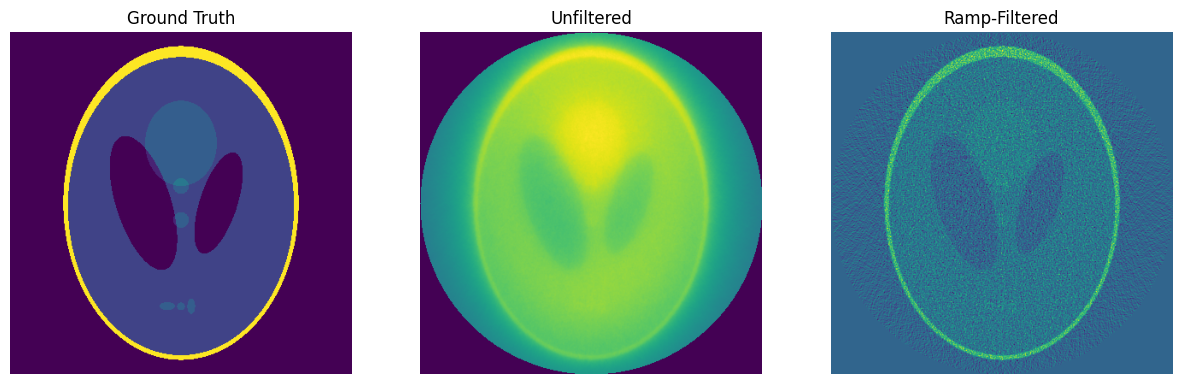


The unfiltered reconstruction has significant blurring in the image. 
Meanwhile, the ramp-filtered reconstruction reduces this blurring significantly,
at the cost of having strongly visible noise in the reconstructed image.
There don't appear to be any streak artifacts in either image;
this is likely because we have enough projection angles to prevent them.
The small, low-contrast spots in the ground-truth image 
(similar to lesions) are not visible in either reconstruction;
in the unfiltered image, the spatial resolution is too low to make them out,
and in the ramp-filtered image, they are indistinguishable from noise.
This suggests that either method provides poor lesion visibility, 
and we must use a different type of filter or an interative reconstruction instead.



In [27]:
print("=== Coding Exercise 2: PET Phantom Reconstruction ===")

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import rotate

# Suggested baseline settings (you may change these)
image_size = 128
angles_deg = np.linspace(0.0, 180.0, 60, endpoint=False)
total_counts = 400_000

# TODO 1: Create a 2D phantom with:
# - Uniform background uptake
# - At least two hot regions (different sizes and/or intensities)
from skimage.data import shepp_logan_phantom
phantom = shepp_logan_phantom()

# TODO 2: Generate a parallel-beam sinogram over multiple projection angles. (Hint: implement a Radon-transform)
from skimage.transform import radon_transform
sinogram = radon_transform.radon(phantom, np.arange(360))

# TODO 3: Scale the sinogram to represent total counts, then add Poisson noise.
noisy_sinogram = sinogram
for (i, j), px in np.ndenumerate(sinogram):
    noisy_sinogram[i][j] = np.random.poisson(px)

# TODO 4: Reconstruct the image using UBP and FBP.
unfiltered_reconstruction = radon_transform.iradon(noisy_sinogram, np.arange(360), filter_name=None)
filtered_reconstruction = radon_transform.iradon(noisy_sinogram, np.arange(360), filter_name="ramp")

# TODO 5: Compare results to ground truth.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,15))
ax1.imshow(phantom); ax1.set_title("Ground Truth"); ax1.axis("off")
ax2.imshow(unfiltered_reconstruction); ax2.set_title("Unfiltered"); ax2.axis("off")
ax3.imshow(filtered_reconstruction); ax3.set_title("Ramp-Filtered"); ax3.axis("off")
plt.show()

# TODO 6: Write a short analysis.
print("""
The unfiltered reconstruction has significant blurring in the image. 
Meanwhile, the ramp-filtered reconstruction reduces this blurring significantly,
at the cost of having strongly visible noise in the reconstructed image.
There don't appear to be any streak artifacts in either image;
this is likely because we have enough projection angles to prevent them.
The small, low-contrast spots in the ground-truth image 
(similar to lesions) are not visible in either reconstruction;
in the unfiltered image, the spatial resolution is too low to make them out,
and in the ramp-filtered image, they are indistinguishable from noise.
This suggests that either method provides poor lesion visibility, 
and we must use a different type of filter or an interative reconstruction instead.
""")

## 3.2 SPECT Clinical Applications

### **Questions 9**
**Hint:** These questions are drawn from Lecture 31 on SPECT clinical use and consolidate concepts from Lectures 29–31.

- a) Myocardial perfusion SPECT (MPS) uses Tc-99m sestamibi or Tl-201. Explain the mechanism by which each tracer accumulates in viable myocardium, and describe what a **reversible defect** indicates versus a **fixed defect**.
- b) Bone scintigraphy uses Tc-99m MDP. Explain the mechanism of skeletal uptake. Give two different clinical scenarios where tomographic SPECT acquisition provides information that a planar bone scan cannot.
- c) Brain perfusion SPECT uses Tc-99m HMPAO. What physiological process is being imaged, and give one clinical application where this technique contributes diagnostic information.
- d) Give one specific clinical example where adding CT to a SPECT acquisition (SPECT/CT) changes clinical management compared to SPECT alone, and explain what the CT component contributes.

## 3.3 Collimator Spatial Resolution Simulation

### **Coding Exercise 3**
Implement a short simulation of parallel-hole collimator spatial resolution versus depth. This exercise is a direct application of the geometric resolution formula from **Lecture 30**.

The geometric spatial resolution (FWHM) at source-to-collimator distance $z$ is:
$$R_g(z) = d \cdot \frac{l_e + z}{l_e}$$

System resolution also includes the intrinsic detector resolution:
$$R_{sys}(z) = \sqrt{R_g(z)^2 + R_{int}^2}$$

**Collimator parameters to use:**

| Collimator | Hole diameter $d$ (mm) | Effective length $l_e$ (mm) |
|---|---|---|
| LEHR (Low Energy High Resolution) | 1.5 | 24.0 |
| LEGP (Low Energy General Purpose) | 2.0 | 27.0 |
| LEUHR (Low Energy Ultra-High Resolution) | 1.0 | 32.0 |

Assume intrinsic detector resolution $R_{int} = 3.5\ \mathrm{mm}$ for all three.

Tasks:
1. Implement `geometric_resolution(d, le, z)` and `system_resolution(d, le, r_int, z)`.
2. Plot system FWHM (mm) vs depth (0–300 mm) for all three collimators.
3. Add a vertical dashed line at 100 mm (10 cm) depth (a typical cardiac imaging depth) and annotate the FWHM value for each collimator there.
4. Write 2–3 sentences interpreting which collimator you would choose for a small superficial organ versus a deep abdominal organ, and what trade-off you accept.

**Helpful Note:** Resolution degrades linearly with depth for a parallel-hole collimator. This is one of the fundamental constraints of planar and SPECT imaging that PET avoids by using electronic collimation.

In [ ]:
print("=== Coding Exercise 3: Collimator Spatial Resolution vs Depth ===")

import matplotlib.pyplot as plt
import numpy as np

# Given in the instructions/table
r_int_mm = 3.5
depth_mm = np.linspace(0.0, 300.0, 301)
cardiac_depth_mm = 100.0

# TODO 1: Create a collimator parameter dictionary for LEHR, LEGP, LEUHR using d (mm) and l_e (mm) from the markdown table.

# TODO 2: Implement geometric_resolution(d_mm, le_mm, z_mm).

# TODO 3: Implement system_resolution(d_mm, le_mm, r_int_mm, z_mm).

# TODO 4: Plot system FWHM vs depth for all three collimators.

# TODO 5: Add a vertical dashed line at 100 mm and annotate each curve's value there.

# TODO 6: Add labels/title/legend and write 2–3 sentences on clinical trade-offs.

---
# Part 4: Course Reflection

## Course Reflection (Approx. 1/3 page)

Write a concise reflection (about one-third of a page) that highlights your learning and experience in this course. Your response should be written as a short, well-structured paragraph or two, not point form.

In your reflection, aim to address the following ideas in a natural, integrated way:

* The most important concepts or insights you are taking away from the course and why they matter for understanding biomedical imaging
* One area where your understanding meaningfully improved, including how your thinking changed over the term
* How you developed as a problem-solver, with a specific example (e.g., quantitative reasoning, interpreting images, connecting physics to clinical use, coding, or communication)
* One aspect of the course (teaching approach, assignments, or structure) that particularly supported your learning

Focus on clarity, specificity, and reflection on your learning journey. Strong responses will connect course content to skills, understanding, and future applications.


---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. Run all cells in order before submission.
2. **PDF Export** (`.pdf`): Export the notebook to PDF and verify that all equations, figures, and captions render correctly.

**Important:** Complete all answers directly in this notebook.

**File naming convention:** `LastName_FirstName_Deliverable5.ipynb` and `.pdf`

**Due:** Tuesday, April 14, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Coding Exercises Due |
|---------|--------------------------------|
| **Part 1: Radioactivity, Radiotracers, and Counting Fundamentals** | Q1 (a, b, c), Q2 (a, b, c), Coding Exercise 1, Q3 (a, b, c, d), Q4 (a, b, c, d) |
| **Part 2: Gamma Camera Imaging, SPECT, and Image Corrections** | Q5 (a, b, c, d), Q6 (a, b, c, d) |
| **Part 3: PET Physics and Imaging Systems** | Q7 (a, b, c), Q8 (a, b, c), Coding Exercise 2, Q9 (a, b, c, d), Coding Exercise 3 |
| **Part 4: Course Reflection** | Written reflection (~1/3 page) |